In [ ]:
import sys
!conda install --yes --prefix {sys.prefix} pandas matplotlib seaborn

In [5]:
import pandas as pd

# Load all datasets
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [7]:
# How many rows and columns?
print("Orders shape:", orders.shape)

Orders shape: (99441, 8)


In [9]:
print("Customers shape:", customers.shape)

Customers shape: (99441, 5)


In [11]:
print("Order items shape:", order_items.shape)

Order items shape: (112650, 7)


In [13]:
print("Payments shape:", payments.shape)

Payments shape: (103886, 5)


In [15]:
print("Reviews shape:", reviews.shape)

Reviews shape: (99224, 7)


In [17]:
print("Products shape:", products.shape)

Products shape: (32951, 9)


In [21]:
# Preview the orders table
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [23]:
# See column names and data types
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [25]:
# Check for missing values
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [27]:
# Convert date columns to proper datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("Dates fixed!")

Dates fixed!


In [29]:
# Keep only delivered orders for clean analysis
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Total delivered orders: {len(orders_delivered)}")

Total delivered orders: 96478


In [31]:
# How many days did delivery take?
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

orders_delivered['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [33]:
# Merge orders + payments + reviews into one master table
df = orders_delivered.merge(payments, on='order_id', how='left')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

print("Master table shape:", df.shape)
df.head()

Master table shape: (101326, 14)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1.0,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,3.0,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1.0,credit_card,3.0,179.12,5.0


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

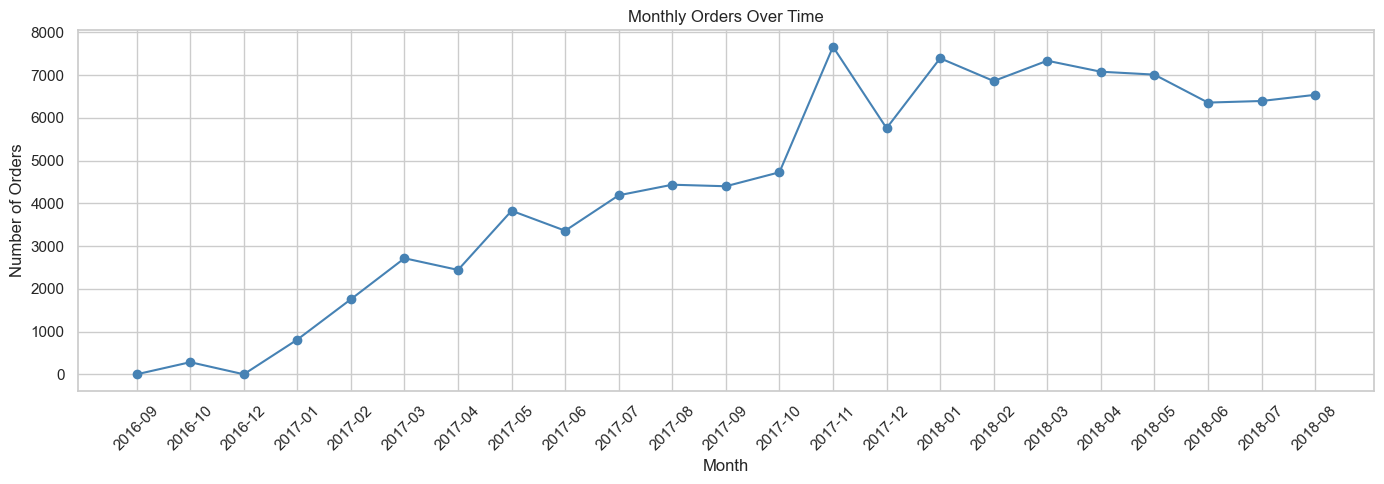

In [37]:
# Extract month from order date
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('order_month').size().reset_index(name='order_count')

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['order_month'].astype(str), monthly_orders['order_count'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Orders Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('monthly_orders.png')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21028\3124688738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='review_score', palette='Blues')


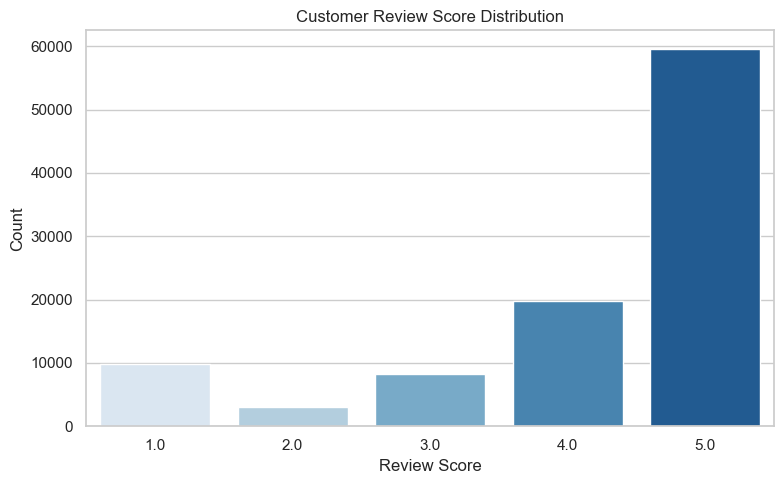

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score', palette='Blues')
plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('review_scores.png')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21028\1945447778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='review_score', y='delivery_days', palette='coolwarm')


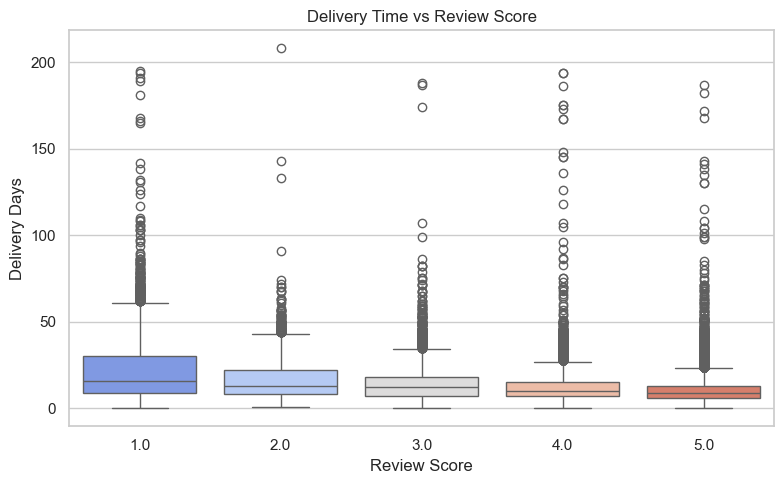

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='review_score', y='delivery_days', palette='coolwarm')
plt.title('Delivery Time vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.savefig('delivery_vs_review.png')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21028\1945447778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='review_score', y='delivery_days', palette='coolwarm')


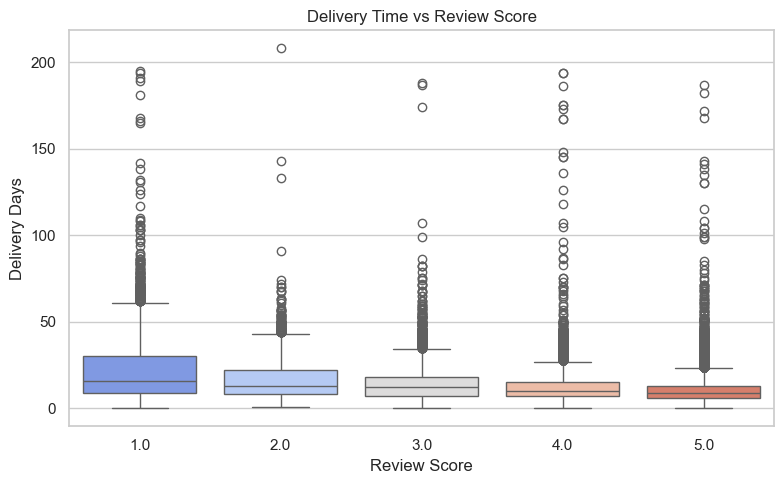

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='review_score', y='delivery_days', palette='coolwarm')
plt.title('Delivery Time vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.savefig('delivery_vs_review.png')
plt.show()

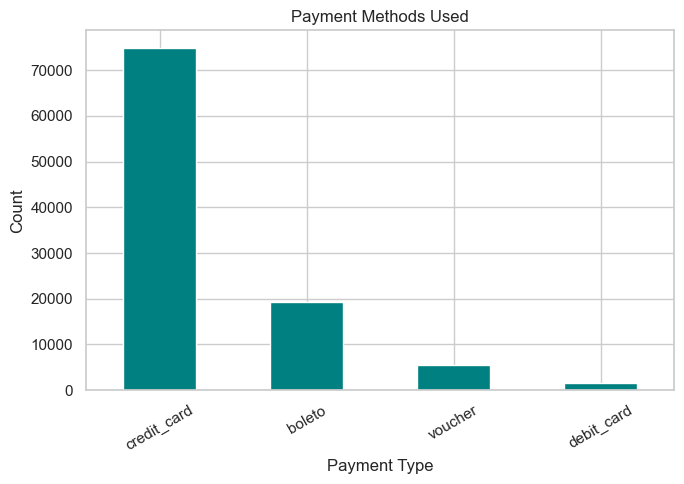

In [47]:
payment_counts = df['payment_type'].value_counts()

plt.figure(figsize=(7, 5))
payment_counts.plot(kind='bar', color='teal')
plt.title('Payment Methods Used')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('payment_methods.png')
plt.show()